# ENG-03: Artifact Rejection (ICA + ICLabel)

This notebook walks through every step of the ENG-03 pipeline on **one patient session**,
with plots at each stage so you can visually verify the results.

**Classification strategy:** ICLabel neural-network classifier (primary) with
correlation-based detection as an automatic fallback.

**Prerequisite:** ENG-02 aligned events must exist for the patient you choose.

In [1]:
import os
import sys

# This notebook lives in awaken-ai/eda/.
# Go up one level to awaken-ai/ so that "from src.…" imports work.
os.chdir(os.path.join(os.path.abspath("."), ".."))
sys.path.insert(0, os.getcwd())

import matplotlib.pyplot as plt  # noqa: E402
import mne  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402

%matplotlib inline
mne.set_log_level("WARNING")

# Check ICLabel availability
try:
    import mne_icalabel  # noqa: E402

    _icalabel_ver = mne_icalabel.__version__
except ImportError:
    _icalabel_ver = "NOT INSTALLED (will fall back to correlation)"

print(f"MNE {mne.__version__}  •  NumPy {np.__version__}  •  pandas {pd.__version__}  •  ICLabel {_icalabel_ver}")

MNE 1.11.0  •  NumPy 1.26.4  •  pandas 2.2.3  •  ICLabel 0.8.1


## 0. Configure — pick a patient + session

Change `PATIENT_ID` and `SESSION_DATE` below to match a patient for which ENG-02 has produced aligned events.

In [2]:
PATIENT_ID = "CON008"  # <── change me
SESSION_DATE = "2025-08-14"  # <── change me

## 1. Load inputs  (`UnifiedDataLoader` + aligned events)

In [3]:
from src.data_loading import config
from src.data_loading.unified_data_loader import UnifiedDataLoader

loader = UnifiedDataLoader(verbose=False)

# Load EDF
raw = loader.load_edf(PATIENT_ID, date=SESSION_DATE, use_clipped=True)
print(f"EDF loaded: {len(raw.ch_names)} channels, {raw.times[-1]:.1f}s, sfreq={raw.info['sfreq']}Hz")
print(f"Channels: {raw.ch_names}")

2026-02-16 20:46:27,112 - src.data_loading.unified_data_loader - Loading unified data from unified_stimulus_results.parquet
2026-02-16 20:46:27,187 - src.data_loading.unified_data_loader - Schema validation passed
2026-02-16 20:46:27,188 - src.data_loading.unified_data_loader - Loaded 1603 trials from 14 patients
2026-02-16 20:46:27,189 - src.data_loading.unified_data_loader - Loading specific session for CON008: 2025-08-14
2026-02-16 20:46:27,190 - src.data_loading.unified_data_loader - Loading EDF for CON008 (2025-08-14): CON008_clipped.EDF


EDF loaded: 50 channels, 3866.0s, sfreq=512.0Hz
Channels: ['C3', 'C4', 'O1', 'O2', 'FT9', 'FT10', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fz', 'Fp1', 'Fp2', 'Fpz', 'P3', 'P4', 'Pz', 'T7', 'T8', 'P7', 'P8', 'IO1', 'IO2', 'EMG1', 'EMG2', 'ECGL', 'ECGR', 'LAT1', 'LAT2', 'RAT1', 'RAT2', 'RESP', 'ABD', 'FLOW', 'SNORE', 'DIF5', 'DIF6', 'POS', 'DC2', 'DC3', 'DC4', 'DC5', 'DC6', 'DC7', 'DC8', 'DC9', 'DC10', 'OSAT', 'PR']


/Users/riddheshsawant/Downloads/Capstone/awaken-ai/src/data_loading/unified_data_loader.py:247: RuntimeWarning: Omitted 5 annotation(s) that were outside data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=self.verbose)


In [4]:
# Load aligned events from ENG-02
aligned_path = config.ALIGNED_EVENTS_DIR / f"{PATIENT_ID}_events.parquet"
# .resolve() follows the symlink so pandas can open the real file
aligned_df = pd.read_parquet(aligned_path.resolve())
session_df = aligned_df[aligned_df["date"] == SESSION_DATE].copy()

print(f"Aligned events: {len(session_df)} trials for {PATIENT_ID} on {SESSION_DATE}")
session_df.groupby("trial_type").size()

Aligned events: 82 trials for CON008 on 2025-08-14


trial_type
language         72
left_command      3
oddball           4
right_command     3
dtype: int64

## 2. Inspect channels — which are EEG vs non-EEG?

In [5]:
from src.data_processing.artifact_rejection import _find_eog_channels, _pick_eeg_indices
from src.utils.signal_processing import exclude_non_eeg_channels

non_eeg = exclude_non_eeg_channels(raw)
eeg_picks = _pick_eeg_indices(raw)
eeg_names = [raw.ch_names[i] for i in eeg_picks]
eog_chs = _find_eog_channels(raw)

print(f"Total channels in EDF: {len(raw.ch_names)}")
print(f"Non-EEG channels EXCLUDED ({len(non_eeg)}): {non_eeg}")
print(f"EEG channels for ICA ({len(eeg_names)}): {eeg_names}")
print(f"EOG reference channels (for blink detection): {eog_chs}")

Total channels in EDF: 50
Non-EEG channels EXCLUDED (28): ['IO1', 'IO2', 'EMG1', 'EMG2', 'ECGL', 'ECGR', 'LAT1', 'LAT2', 'RAT1', 'RAT2', 'RESP', 'ABD', 'FLOW', 'SNORE', 'DIF5', 'DIF6', 'POS', 'DC2', 'DC3', 'DC4', 'DC5', 'DC6', 'DC7', 'DC8', 'DC9', 'DC10', 'OSAT', 'PR']
EEG channels for ICA (22): ['C3', 'C4', 'O1', 'O2', 'FT9', 'FT10', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fz', 'Fp1', 'Fp2', 'Fpz', 'P3', 'P4', 'Pz', 'T7', 'T8', 'P7', 'P8']
EOG reference channels (for blink detection): ['IO1', 'IO2']


### Plot: Raw EEG (first 10 seconds, before any cleaning)

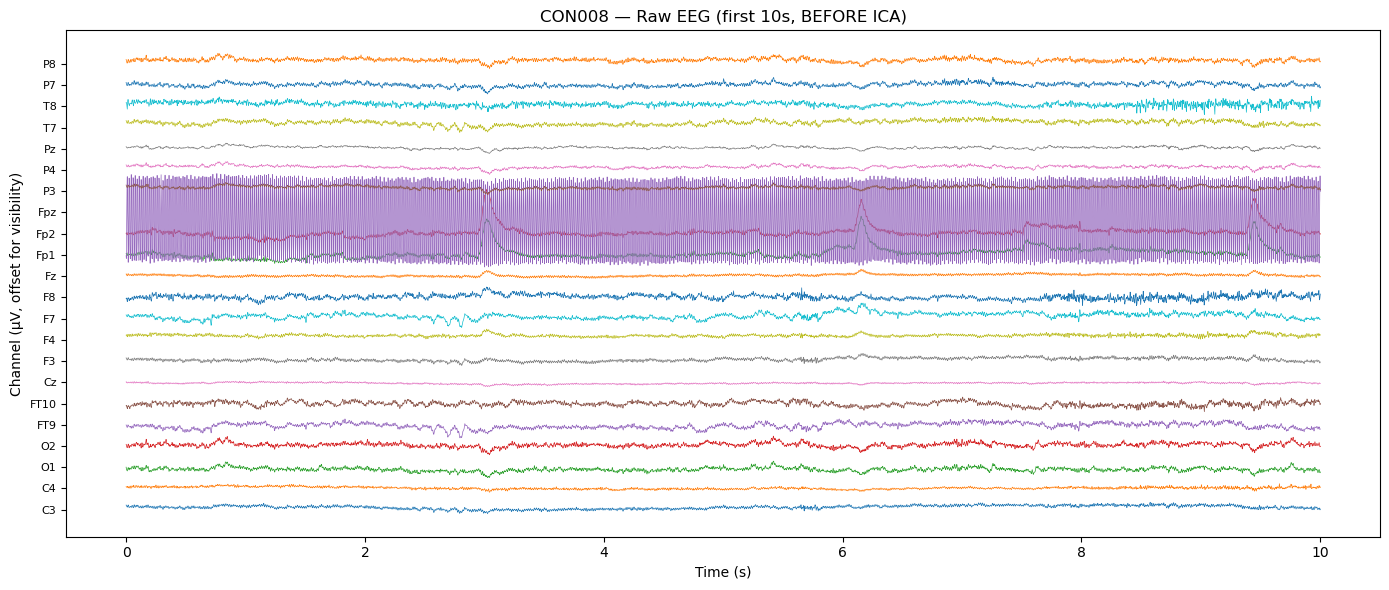

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
start_sec, end_sec = 0, 10
data_raw = raw.copy().pick(eeg_names).get_data(tmin=start_sec, tmax=end_sec) * 1e6  # to µV
times = np.linspace(start_sec, end_sec, data_raw.shape[1])

offsets = np.arange(len(eeg_names)) * 150  # µV spacing
for i, ch in enumerate(eeg_names):
    ax.plot(times, data_raw[i] + offsets[i], lw=0.5, label=ch)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Channel (µV, offset for visibility)")
ax.set_title(f"{PATIENT_ID} — Raw EEG (first {end_sec}s, BEFORE ICA)")
ax.set_yticks(offsets)
ax.set_yticklabels(eeg_names, fontsize=8)
plt.tight_layout()
plt.show()

## 3. Timezone offset detection

In [7]:
from src.utils.time_utils import detect_timezone_offset, unix_to_edf

tz_offset = detect_timezone_offset(raw, session_df)
edf_start_unix = raw.info["meas_date"].timestamp()

print(f"EDF meas_date (unix): {edf_start_unix:.2f}")
print(f"First trial start (unix): {session_df['start_time'].min():.2f}")
print(f"Detected timezone offset: {tz_offset:.0f}s  ({tz_offset / 3600:.1f}h)")

# Quick sanity check: convert first trial start → EDF seconds
first_start_edf = unix_to_edf(session_df["start_time"].min(), edf_start_unix=edf_start_unix, timezone_offset=tz_offset)
print(f"First trial in EDF time: {first_start_edf:.2f}s")

2026-02-16 20:46:33,633 - src.utils.time_utils - Timezone offset detected: -7.0 hours


EDF meas_date (unix): 1755181518.00
First trial start (unix): 1755207296.46
Detected timezone offset: -25200s  (-7.0h)
First trial in EDF time: 578.46s


## 4. ICA-Based Artifact Rejection (ICLabel + Correlation Fallback)

The pipeline uses a **two-stage classification strategy**:

1. **Primary — ICLabel** (neural-network classifier): detects 7 artifact types
   (eye, muscle, heart, line noise, channel noise, brain, other).
   Requires a standard 10-20 montage and CAR reference.
2. **Fallback — Correlation** (`find_bads_eog` / `find_bads_ecg` / `find_bads_muscle`):
   used automatically when ICLabel cannot run (e.g. montage setup fails).

**Workflow**: filter → montage → CAR → fit ICA (Extended Infomax) → classify → apply.

In [8]:
from src.data_processing.artifact_rejection import (  # noqa: E402
    DEFAULT_ICA_FILTER_HZ,
    DEFAULT_ICLABEL_THRESHOLD,
    ArtifactRejector,
    _apply_and_summarize,
    _apply_car_reference,
    _classify_components_correlation,
    _classify_components_iclabel,
    _fit_ica,
    _prepare_ica_data,
    _try_set_montage,
)

ar = ArtifactRejector(verbose=False)

# ── Step 1: Prepare ICA data (copy, set non-EEG types, bandpass filter) ──
raw_for_ica, picks_eeg, notes = _prepare_ica_data(raw, DEFAULT_ICA_FILTER_HZ, verbose=False)
print(f"Step 1 - Prepared: {len(picks_eeg)} EEG channels, filter={DEFAULT_ICA_FILTER_HZ}")

# ── Step 2: Set standard 10-20 montage (needed for ICLabel topographic features) ──
montage_ok = _try_set_montage(raw_for_ica, notes)
print(f"Step 2 - Montage: {'set successfully' if montage_ok else 'skipped (too few 10-20 matches)'}")

# ── Step 3: Apply Common Average Reference (ICLabel was trained on CAR data) ──
if montage_ok:
    _apply_car_reference(raw_for_ica, notes)
    print("Step 3 - CAR: applied to EEG channels")
else:
    print("Step 3 - CAR: skipped (no montage)")

# ── Step 4: Fit ICA (Extended Infomax) ──
ica = _fit_ica(raw_for_ica, picks_eeg)
print(f"Step 4 - ICA fitted: {ica.n_components_} components (method={ica.method})")

2026-02-16 20:46:43,018 - src.data_loading.unified_data_loader - Loading unified data from unified_stimulus_results.parquet
2026-02-16 20:46:43,025 - src.data_loading.unified_data_loader - Schema validation passed
2026-02-16 20:46:43,026 - src.data_loading.unified_data_loader - Loaded 1603 trials from 14 patients
/Users/riddheshsawant/Downloads/Capstone/awaken-ai/src/data_processing/artifact_rejection.py:203: RuntimeWarning: The unit for channel(s) ABD, DC10, DC2, DC3, DC4, DC5, DC6, DC7, DC8, DC9, DIF5, DIF6, ECGL, ECGR, EMG1, EMG2, FLOW, IO1, IO2, LAT1, LAT2, OSAT, POS, PR, RAT1, RAT2, RESP, SNORE has changed from V to NA.
  raw_for_ica.set_channel_types(type_map)


Step 1 - Prepared: 22 EEG channels, filter=(1.0, 100.0)
Step 2 - Montage: set successfully
Step 3 - CAR: applied to EEG channels
Step 4 - ICA fitted: 8 components (method=infomax)


In [9]:
# ── Step 5: Classify – ICLabel (primary), correlation (fallback) ──
classification = None
method = "correlation"

if montage_ok:
    classification = _classify_components_iclabel(raw_for_ica, ica, notes, threshold=DEFAULT_ICLABEL_THRESHOLD)
    if classification is not None:
        method = "iclabel"
        print(
            f"ICLabel: classified {len(classification['excluded'])} artifact component(s) "
            f"(threshold={DEFAULT_ICLABEL_THRESHOLD})"
        )

if classification is None:
    classification = _classify_components_correlation(raw_for_ica, ica, notes)
    print(f"Correlation fallback: classified {len(classification['excluded'])} artifact component(s)")

# ── Step 6: Apply exclusions to original (unfiltered) raw ──
raw_clean, ica_summary = _apply_and_summarize(raw, ica, classification, method, notes)

print("\n─── ICA Summary ───")
print(f"ICA method:          {ica_summary.method}")
print(f"Classification:      {ica_summary.classification_method}")
print(f"Components fit:      {ica_summary.n_components}")
print(f"EOG channels used:   {ica_summary.eog_channels_used}")
print(f"EOG components:      {ica_summary.eog_components}")
print(f"ECG channels used:   {ica_summary.ecg_channels_used}")
print(f"ECG components:      {ica_summary.ecg_components}")
print(f"Muscle components:   {ica_summary.muscle_components}")
print(f"Line noise comps:    {ica_summary.line_noise_components}")
print(f"Channel noise comps: {ica_summary.channel_noise_components}")
print(f"TOTAL excluded:      {ica_summary.excluded}")

if ica_summary.iclabel_labels:
    print("\n─── ICLabel per-component labels ───")
    for idx, label in enumerate(ica_summary.iclabel_labels):
        marker = " ** EXCLUDED **" if idx in ica_summary.excluded else ""
        print(f"  IC{idx:02d}: {label}{marker}")

print("\nNotes:")
for n in ica_summary.notes:
    print(f"  {n}")

# Sanity check: did ICA actually change the signal?
seg_before = raw.copy().pick(eeg_names).get_data(tmin=0, tmax=30) * 1e6
seg_after = raw_clean.copy().pick(eeg_names).get_data(tmin=0, tmax=30) * 1e6
mad = np.mean(np.abs(seg_before - seg_after))
print(f"\nMean absolute difference (first 30s, uV): {mad:.3f}")
if mad < 0.01:
    print("WARNING: Difference ~ 0 -- ICA may not have excluded any components.")

ICLabel: classified 5 artifact component(s) (threshold=0.5)

─── ICA Summary ───
ICA method:          infomax
Classification:      iclabel
Components fit:      8
EOG channels used:   []
EOG components:      []
ECG channels used:   []
ECG components:      []
Muscle components:   []
Line noise comps:    []
Channel noise comps: []
TOTAL excluded:      [0, 1, 2, 3, 7]

─── ICLabel per-component labels ───
  IC00: line noise ** EXCLUDED **
  IC01: line noise ** EXCLUDED **
  IC02: eye blink ** EXCLUDED **
  IC03: eye blink ** EXCLUDED **
  IC04: brain
  IC05: brain
  IC06: brain
  IC07: muscle artifact ** EXCLUDED **

Notes:
  [CHANNELS] non_eeg_excluded=['IO1', 'IO2', 'EMG1', 'EMG2', 'ECGL', 'ECGR', 'LAT1', 'LAT2', 'RAT1', 'RAT2', 'RESP', 'ABD', 'FLOW', 'SNORE', 'DIF5', 'DIF6', 'POS', 'DC2', 'DC3', 'DC4', 'DC5', 'DC6', 'DC7', 'DC8', 'DC9', 'DC10', 'OSAT', 'PR']
  [CHANNELS] n_eeg=22
  [MONTAGE] set	matched=22/22
  [REFERENCE] CAR applied
  [ICLABEL] excluded=5 (eye=0, heart=0, muscle=0, li

### ICA Component Topographies

Visual inspection of the spatial patterns of each ICA component.
Excluded components (artifacts) should show patterns consistent with
eye blinks, muscle activity, heartbeat, or line noise.

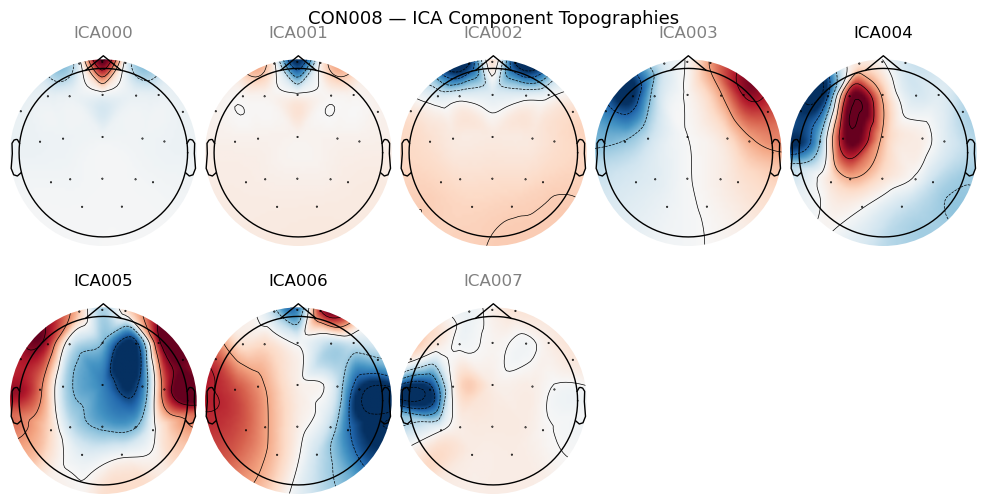

Excluded components: [0, 1, 2, 3, 7]


In [10]:
# Plot ICA component topographies (available when montage is set)
if montage_ok and ica.n_components_ > 0:
    n_show = min(20, ica.n_components_)
    figs = ica.plot_components(picks=range(n_show), show=False)
    if not isinstance(figs, list):
        figs = [figs]
    for f in figs:
        f.suptitle(f"{PATIENT_ID} — ICA Component Topographies", fontsize=13, y=1.02)
    plt.show()
    if ica_summary.excluded:
        print(f"Excluded components: {ica_summary.excluded}")
else:
    print("Topographic maps not available (montage was not set).")

### Plot: Before vs After ICA (overlay same 10 seconds)

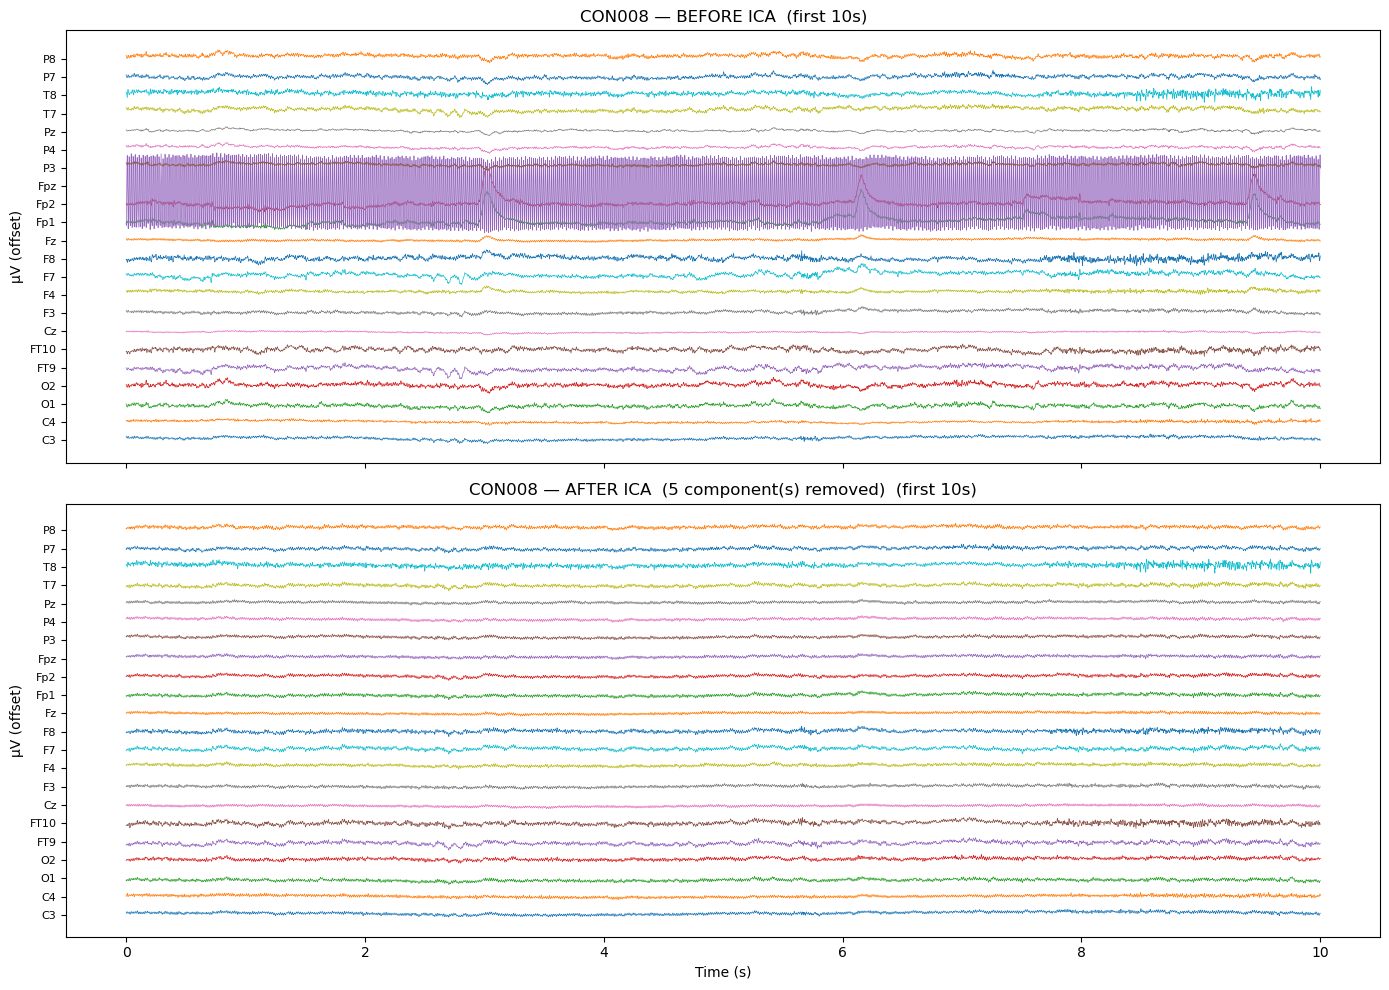

Per-channel mean |diff| (µV):
     C3: 9.53
     C4: 8.38
     O1: 11.31
     O2: 11.82
    FT9: 13.64
   FT10: 13.99
     Cz: 7.46
     F3: 11.42
     F4: 10.76
     F7: 17.10
     F8: 14.29
     Fz: 9.61
    Fp1: 25.87
    Fp2: 23.38
    Fpz: 190.92
     P3: 9.74
     P4: 9.21
     Pz: 7.87
     T7: 35.18
     T8: 11.08
     P7: 11.31
     P8: 11.75


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

data_before = raw.copy().pick(eeg_names).get_data(tmin=start_sec, tmax=end_sec) * 1e6
data_after = raw_clean.copy().pick(eeg_names).get_data(tmin=start_sec, tmax=end_sec) * 1e6
times = np.linspace(start_sec, end_sec, data_before.shape[1])

n_excluded = len(ica_summary.excluded)
for ax, data, title in [
    (axes[0], data_before, "BEFORE ICA"),
    (axes[1], data_after, f"AFTER ICA  ({n_excluded} component(s) removed)"),
]:
    offsets = np.arange(len(eeg_names)) * 150
    for i, ch in enumerate(eeg_names):
        ax.plot(times, data[i] + offsets[i], lw=0.5)
    ax.set_title(f"{PATIENT_ID} — {title}  (first {end_sec}s)")
    ax.set_yticks(offsets)
    ax.set_yticklabels(eeg_names, fontsize=8)
    ax.set_ylabel("µV (offset)")

axes[1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

# Per-channel difference summary
diff_per_ch = np.mean(np.abs(data_before - data_after), axis=1)
print("Per-channel mean |diff| (µV):")
for ch, d in zip(eeg_names, diff_per_ch):
    print(f"  {ch:>5s}: {d:.2f}")

### Plot: Difference signal (what ICA removed)

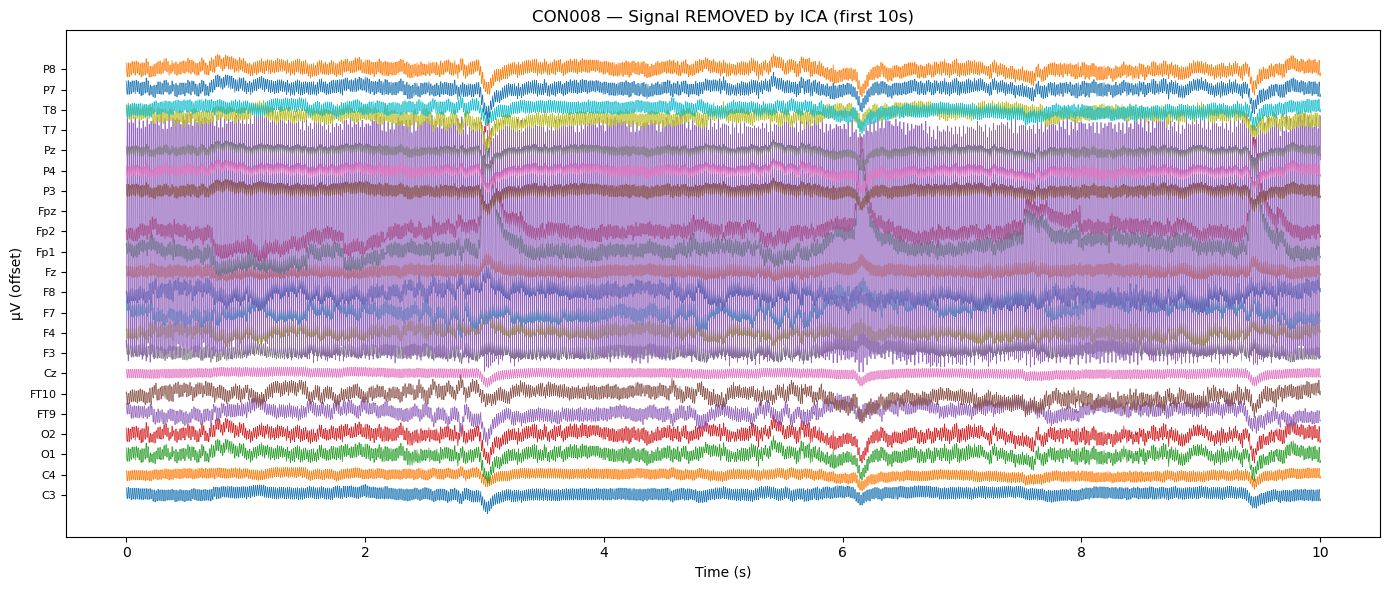

In [12]:
diff = data_before - data_after

fig, ax = plt.subplots(figsize=(14, 6))
offsets = np.arange(len(eeg_names)) * 50
for i, ch in enumerate(eeg_names):
    ax.plot(times, diff[i] + offsets[i], lw=0.5, label=ch)

ax.set_title(f"{PATIENT_ID} — Signal REMOVED by ICA (first {end_sec}s)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("µV (offset)")
ax.set_yticks(offsets)
ax.set_yticklabels(eeg_names, fontsize=8)
plt.tight_layout()
plt.show()

## 5. Build fixed-window epochs for one trial type

In [13]:
from src.data_processing.artifact_rejection import _trial_type_window_sec

# Pick the trial type with the most trials for a meaningful demo
tt_counts = session_df.groupby(session_df["trial_type"].str.lower()).size().sort_values(ascending=False)
print("Trial type counts:")
print(tt_counts)

DEMO_TT = tt_counts.index[0]
print(f'\nUsing trial type: "{DEMO_TT}"  (window = {_trial_type_window_sec(DEMO_TT, None)}s)')

Trial type counts:
trial_type
language         72
oddball           4
left_command      3
right_command     3
dtype: int64

Using trial type: "language"  (window = 16.0s)


In [14]:
tt_df = session_df[session_df["trial_type"].str.lower() == DEMO_TT].copy()

epochs = ar._build_fixed_window_epochs(
    raw_clean,
    tt_df,
    trial_type=DEMO_TT,
    edf_start_unix=edf_start_unix,
    timezone_offset=tz_offset,
)

print(f"Epochs created: {len(epochs)}")
print(f"Channels in epochs: {epochs.ch_names}")
print(f"Epoch time window: {epochs.tmin}s → {epochs.tmax}s")
print(f"Data shape: {epochs.get_data().shape}  (n_epochs, n_channels, n_times)")

Epochs created: 72
Channels in epochs: ['C3', 'C4', 'O1', 'O2', 'FT9', 'FT10', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fz', 'Fp1', 'Fp2', 'Fpz', 'P3', 'P4', 'Pz', 'T7', 'T8', 'P7', 'P8']
Epoch time window: 0.0s → 16.0s
Data shape: (72, 22, 8193)  (n_epochs, n_channels, n_times)


### Plot: A few individual epochs (overlay channels)

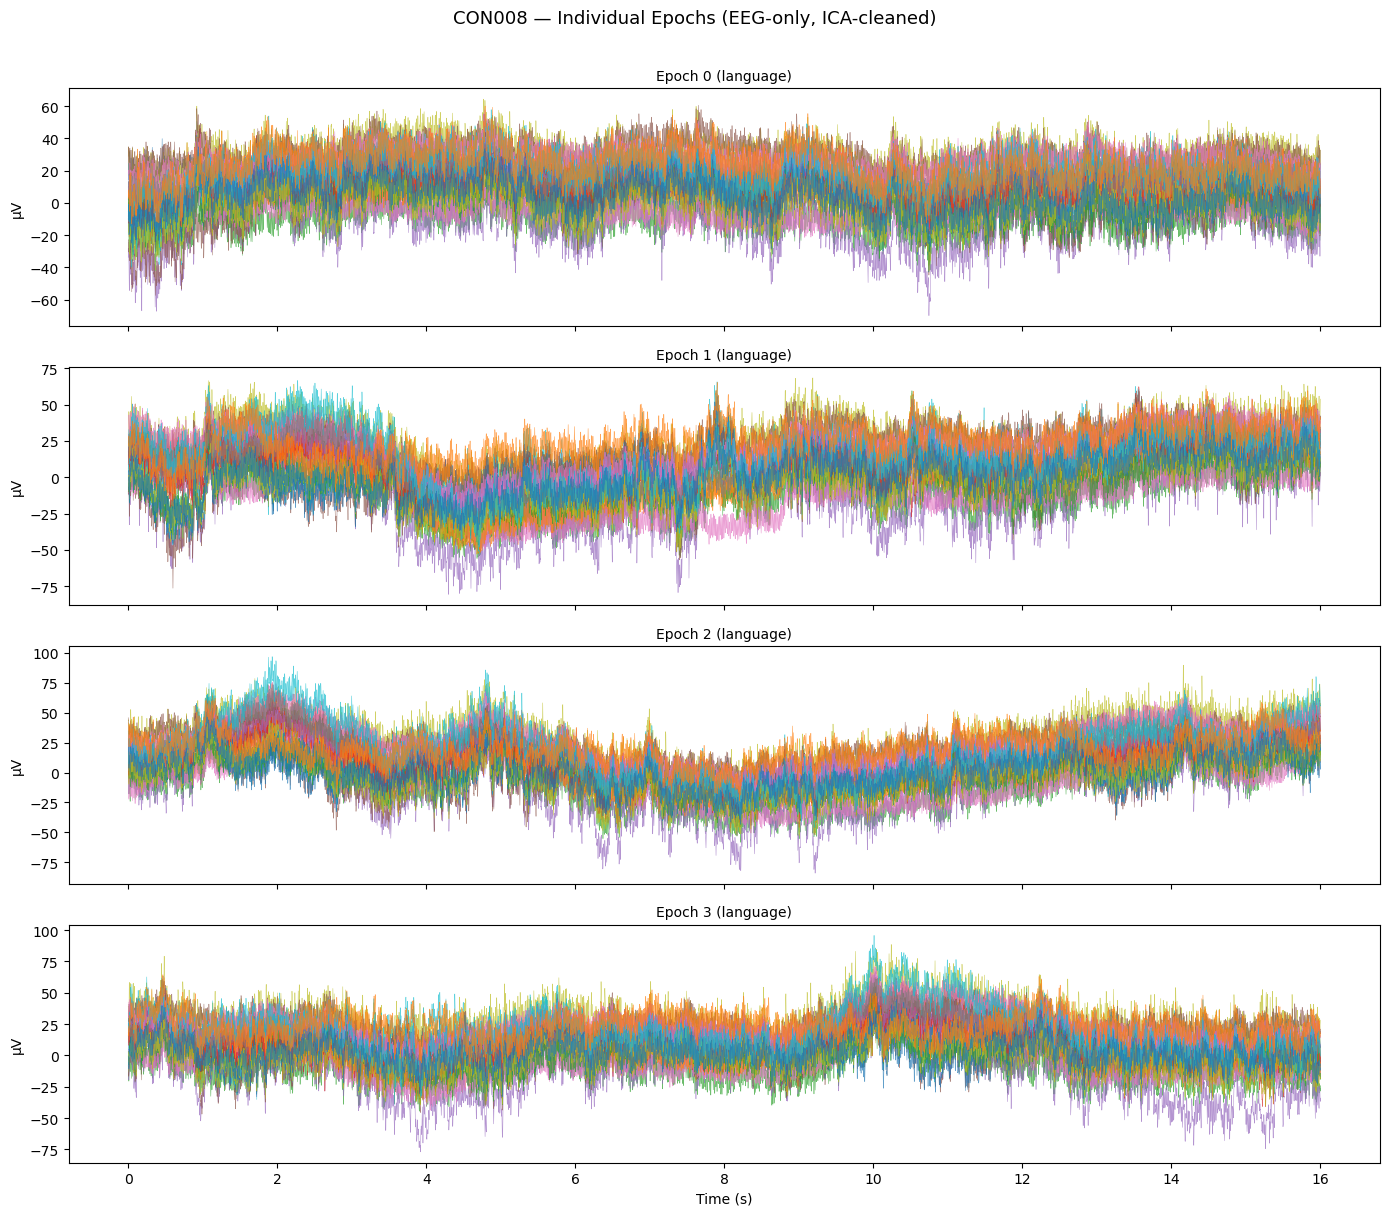

In [15]:
n_show = min(4, len(epochs))
fig, axes = plt.subplots(n_show, 1, figsize=(14, 3 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]

ep_data = epochs.get_data() * 1e6  # µV
ep_times = epochs.times

for i in range(n_show):
    ax = axes[i]
    for ch_idx in range(ep_data.shape[1]):
        ax.plot(ep_times, ep_data[i, ch_idx], lw=0.4, alpha=0.7)
    ax.set_title(f"Epoch {i} ({DEMO_TT})", fontsize=10)
    ax.set_ylabel("µV")

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"{PATIENT_ID} — Individual Epochs (EEG-only, ICA-cleaned)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 6. Peak-to-peak (PTP) distribution & auto-rejection

In [16]:
from src.data_processing.artifact_rejection import _epoch_ptp_uv

ptp_uv = _epoch_ptp_uv(epochs)
threshold = np.percentile(ptp_uv, 95)

print("PTP distribution (µV):")
print(f"  min={ptp_uv.min():.1f}  median={np.median(ptp_uv):.1f}  p95={threshold:.1f}  max={ptp_uv.max():.1f}")
print(f"Epochs above p95 threshold: {(ptp_uv > threshold).sum()} / {len(ptp_uv)}")

PTP distribution (µV):
  min=101.4  median=142.8  p95=311.8  max=695.3
Epochs above p95 threshold: 4 / 72


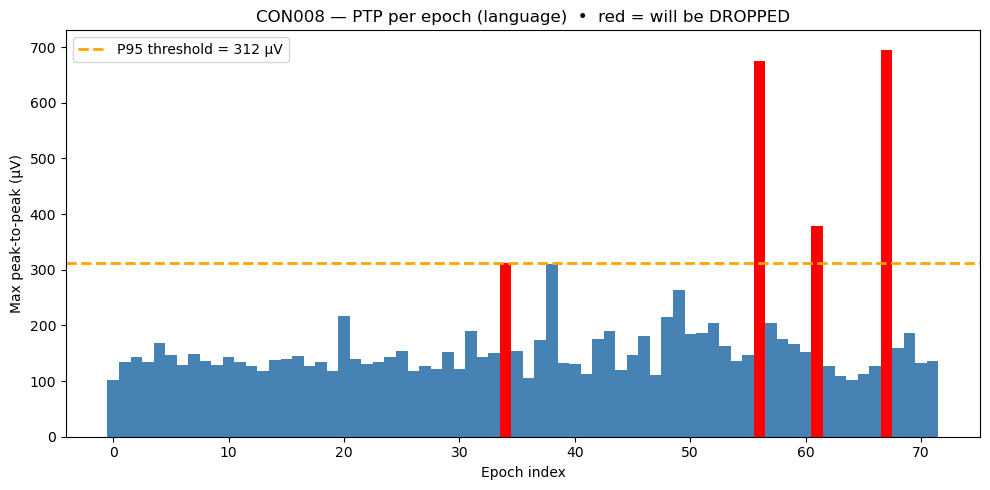

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["red" if v > threshold else "steelblue" for v in ptp_uv]
ax.bar(range(len(ptp_uv)), ptp_uv, color=colors, width=1.0, edgecolor="none")
ax.axhline(threshold, color="orange", ls="--", lw=2, label=f"P95 threshold = {threshold:.0f} µV")
ax.set_xlabel("Epoch index")
ax.set_ylabel("Max peak-to-peak (µV)")
ax.set_title(f"{PATIENT_ID} — PTP per epoch ({DEMO_TT})  •  red = will be DROPPED")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Now actually apply the rejection
epochs_clean, thresh_uv, dropped_idx = ar._auto_reject_epochs(epochs.copy())

print(f"Before: {len(epochs)} epochs")
print(f"Threshold: {thresh_uv:.1f} µV (p95)")
print(f"Dropped: {len(dropped_idx)} epochs (indices: {dropped_idx})")
print(f"After: {len(epochs_clean)} epochs")

Before: 72 epochs
Threshold: 311.8 µV (p95)
Dropped: 4 epochs (indices: [34, 56, 61, 67])
After: 68 epochs


## 7. Grand average (across surviving epochs)

This is the simplest sanity check: average all kept epochs to see if a clean signal emerges.

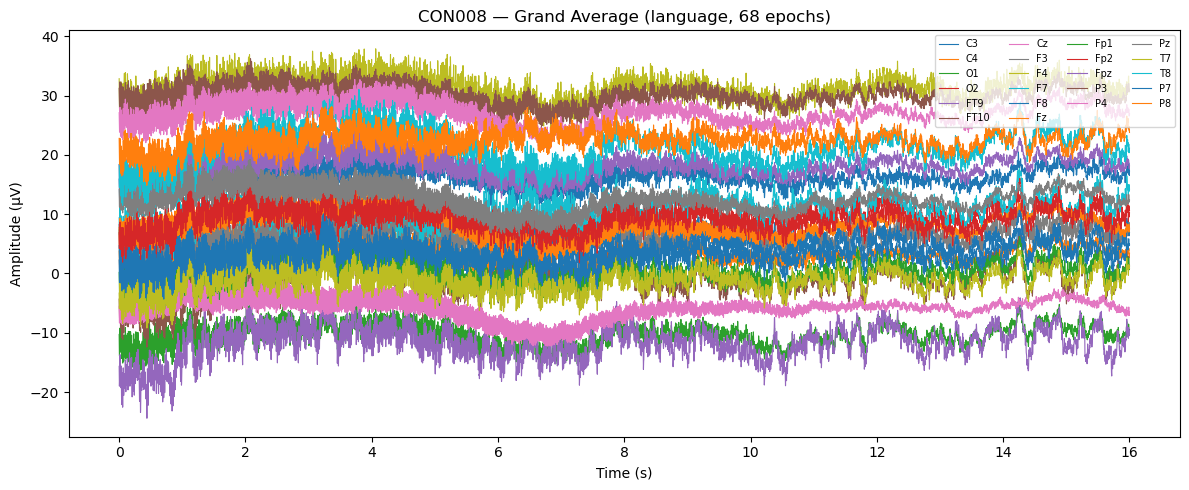

In [19]:
evoked = epochs_clean.average()

fig, ax = plt.subplots(figsize=(12, 5))
evoked_data = evoked.data * 1e6  # µV
for i, ch in enumerate(evoked.ch_names):
    ax.plot(evoked.times, evoked_data[i], lw=0.8, label=ch)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title(f"{PATIENT_ID} — Grand Average ({DEMO_TT}, {len(epochs_clean)} epochs)")
ax.legend(fontsize=7, ncol=4, loc="upper right")
plt.tight_layout()
plt.show()

## 8. QC metadata preview

This is the same data that gets saved to `eng03_qc.parquet` — one row per trial type.

In [20]:
ptp_stats = ar._ptp_stats(ptp_uv)

qc = ar._qc_row(
    patient_id=PATIENT_ID,
    date=SESSION_DATE,
    trial_type=DEMO_TT,
    n_total=len(epochs),
    n_dropped=len(dropped_idx),
    threshold_uv=thresh_uv,
    ica_summary=ica_summary,
    notes=[],
    ptp_stats=ptp_stats,
    drop_reason="ENG03_PTP_GT_P95" if dropped_idx else None,
)

qc_df = pd.DataFrame([qc])
print("QC row columns:", list(qc_df.columns))
qc_df.T

QC row columns: ['patient_id', 'date', 'trial_type', 'window_sec', 'reject_ptp_percentile', 'reject_ptp_threshold_uv', 'n_epochs_total', 'n_epochs_dropped', 'n_epochs_kept', 'drop_reason', 'ica', 'notes', 'ptp_uv_p50', 'ptp_uv_p95', 'ptp_uv_p99', 'ptp_uv_max', 'ptp_uv_mean']


,0
patient_id,CON008
date,2025-08-14
trial_type,language
window_sec,16.0
reject_ptp_percentile,95.0
reject_ptp_threshold_uv,311.763114
n_epochs_total,72
n_epochs_dropped,4
n_epochs_kept,68
drop_reason,ENG03_PTP_GT_P95


## 9. (Optional) Run the full pipeline end-to-end and inspect outputs

This saves `.fif` epochs + QC parquet to disk.

In [21]:
# Uncomment the lines below to run the full pipeline and save to disk:

# ar_full = ArtifactRejector(verbose=False)
# saved = ar_full.run_session(PATIENT_ID, SESSION_DATE, save=True)
# print("Saved epoch files:")
# for tt, path in saved.items():
#     print(f"  {tt}: {path}")
#
# # Read back the QC parquet
# qc_path = config.QC_DIR / PATIENT_ID / SESSION_DATE / "eng03_qc.parquet"
# if qc_path.exists():
#     qc_full = pd.read_parquet(qc_path)
#     display(qc_full)